# Glycolytic oscillations

This notebook reproduces figures 3A-C from the paper [Glycolytic oscillations](https://doi.org/10.1007/978-3-030-67742-8_4) by Kraikivski, 2021.

$$
\frac{d[\mathrm{Glc}]}{dt} = V_{\mathrm{in}} - V_1
$$

$$
\frac{d[\mathrm{ATP}]}{dt} = -2V_1 + 4V_2 - V_3
$$

$$
\frac{d[\mathrm{FdP}]}{dt} = V_1 - V_2
$$
    

In [1]:
from basico import *
import matplotlib.pyplot as plt

In [2]:
model = new_model(
    name='HW3',
    quantity_unit='mol',
    time_unit='s',
    volume_unit='l',
) 

In [3]:
add_species('Glc', compartment_name='Compartment', initial_concentration=0.5)
add_species('ATP', compartment_name='Compartment', initial_concentration=0.4)
add_species('FdP', compartment_name='Compartment', initial_concentration=0.0)

<CMetab "FdP">

In [4]:
add_parameter('k1', initial_value=0.3)
add_parameter('k2', initial_value=0.1)
add_parameter('k3', initial_value=2.5)
add_parameter('Vin', initial_value=0.2)
add_parameter('K', initial_value=2.0)
add_parameter('A', initial_value=10.0)
add_parameter('P', initial_value=10.0)

<CModelValue "P">

In [5]:
add_function(
    'Rate Law for V1',
    'k1 * Glc * ATP',
    type='irreversible',
    mapping={'k1': 'parameter', 'Glc': 'substrate', 'ATP': 'substrate'},
)
 
add_function(
    'Rate Law for V2',
    'k2 * FdP * (A - ATP) * P',
    type='irreversible',
    mapping={
        'k2': 'parameter',
        'FdP': 'substrate',
        'A': 'parameter',
        'ATP': 'product',
        'P': 'parameter',
    },
)

<CFunction "Rate Law for V2">

In [6]:
add_reaction('Vin', '-> Glc')
set_reaction(
    'Vin', exact=True,
    function='Constant flux (irreversible)',
    mapping={'v': 'Vin'},
)
 
add_reaction('V1', 'Glc + 2 * ATP -> FdP')
set_reaction(
    'V1', exact=True,
    function='Rate Law for V1',
    mapping={'k1': 'k1', 'Glc': 'Glc', 'ATP': 'ATP'},
)
 
add_reaction('V2', 'FdP -> 4 * ATP')
set_reaction(
    'V2', exact=True,
    function='Rate Law for V2',
    mapping={'k2': 'k2', 'FdP': 'FdP', 'A': 'A', 'ATP': 'ATP', 'P': 'P'},
)
 
add_reaction('V3', 'ATP ->')
set_reaction(
    'V3', exact=True,
    function='Henri-Michaelis-Menten (irreversible)',
    mapping={'substrate': 'ATP', 'Km': 'K', 'V': 'k3'},
)
 

In [7]:
get_reactions()

,scheme,flux,particle_flux,function,key,sbml_id,display_name,mapping
name,,,,,,,,
Vin,-> Glc,0.0,0.0,Constant flux (irreversible),Reaction_0,,(Vin),{'v': 'Vin'}
V1,Glc + 2 * ATP -> FdP,0.0,0.0,Rate Law for V1,Reaction_1,,(V1),"{'k1': 'k1', 'Glc': 'Glc', 'ATP': 'ATP'}"
V2,FdP -> 4 * ATP,0.0,0.0,Rate Law for V2,Reaction_2,,(V2),"{'k2': 'k2', 'FdP': 'FdP', 'A': 'A', 'ATP': 'A..."
V3,ATP ->,0.0,0.0,Henri-Michaelis-Menten (irreversible),Reaction_3,,(V3),"{'substrate': 'ATP', 'Km': 'K', 'V': 'k3'}"


In [8]:
def plot_time_course(result, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    for species in ['Glc', 'ATP', 'FdP']:
        ax.plot(result.index, result[species], label=species)
    ax.set_xlabel('Time')
    ax.set_ylabel('Concentration (mol/l)')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()


def plot_phase_plane(result, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(result.ATP, result.Glc)
    ax.set_xlabel('ATP')
    ax.set_ylabel('Glc')
    ax.set_title(title)
    fig.tight_layout()


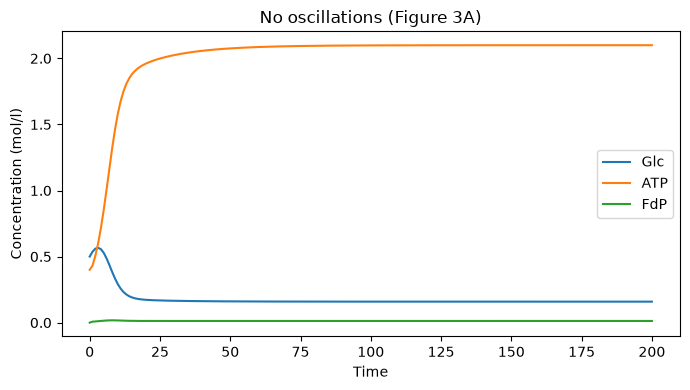

In [9]:
set_parameters('Vin', initial_value=0.1)
set_parameters('k3', initial_value=0.3905)

result = run_time_course(duration=200, intervals=200)
plot_time_course(result, "No oscillations (Figure 3A)")

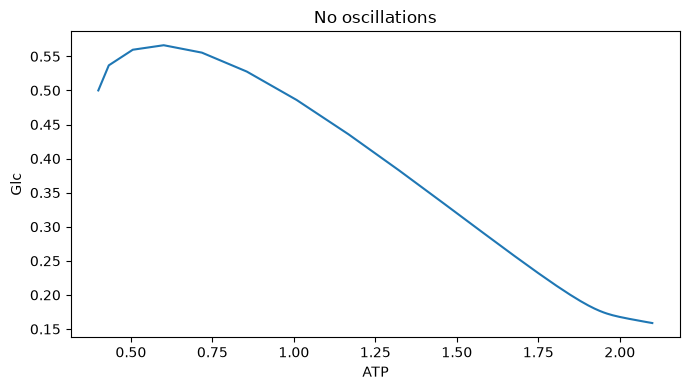

In [10]:
plot_phase_plane(result, "No oscillations")

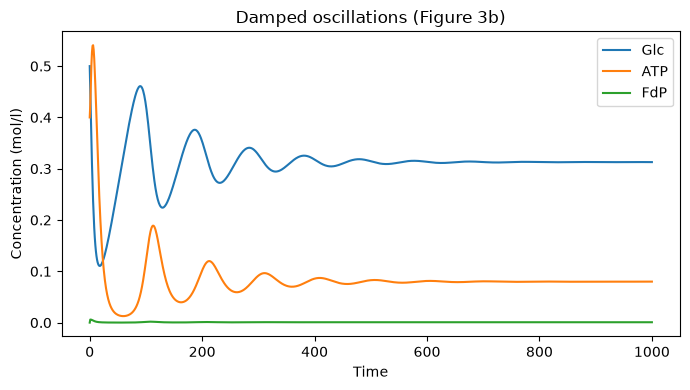

In [11]:
set_parameters('Vin', initial_value=0.0075)
set_parameters('k3', initial_value=0.3905)

result = run_time_course(duration=1000, intervals=1000)
plot_time_course(result, "Damped oscillations (Figure 3b)")

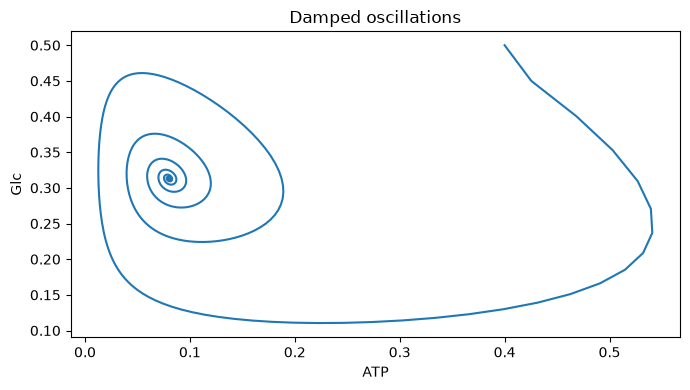

In [12]:
plot_phase_plane(result, "Damped oscillations")

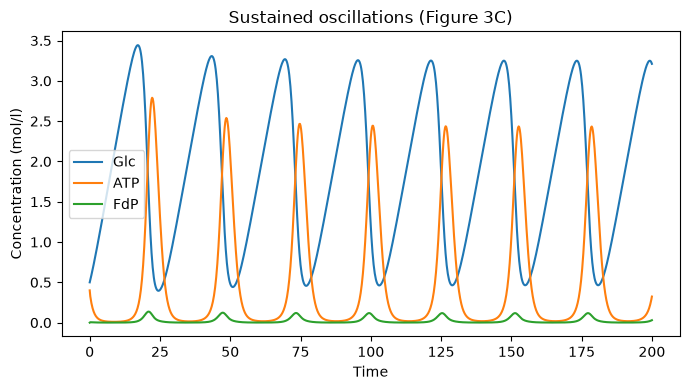

In [17]:
set_parameters('Vin', initial_value=0.2)
set_parameters('k3', initial_value=2.5)

result = run_time_course(duration=200, intervals=1000)
plot_time_course(result, "Sustained oscillations (Figure 3C)")

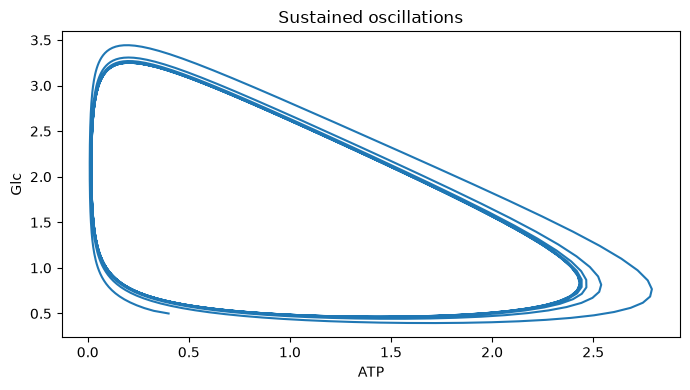

In [18]:
plot_phase_plane(result, "Sustained oscillations")